<a href="https://colab.research.google.com/github/VijayR-Nair/embedded-pump-predictive-maintenance/blob/main/smartsensor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import pandas as pd

sensor = pd.read_csv("/content/sensor.csv")

# print(sensor.shape)
# print(sensor.columns)
# print(sensor["machine_status"].value_counts())

In [90]:
# Find all sensor columns
all_sensors = [c for c in sensor.columns if c.startswith("sensor_")]

# Keep only the columns that are NOT entirely NaN
sensor_cols = [c for c in all_sensors if not sensor[c].isna().all()]

empty_sensor_cols = list(set(all_sensors) - set(sensor_cols))
print(f"Removed empty columns: {empty_sensor_cols}")
print(f"Active sensor count: {len(sensor_cols)}")

Removed empty columns: ['sensor_15']
Active sensor count: 51


In [91]:
normal_sensor = sensor[sensor["machine_status"] == "NORMAL"].copy()

X_normal = normal_sensor[sensor_cols]
X_all = sensor[sensor_cols]

from sklearn.model_selection import train_test_split

X_train_raw, X_val_raw = train_test_split(
    X_normal,
    test_size=0.2,
    shuffle=False
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

# Fit only on training data
X_train_imputed = imputer.fit_transform(X_train_raw)
X_val_imputed = imputer.transform(X_val_raw)

X_train = scaler.fit_transform(X_train_imputed)
X_val = scaler.transform(X_val_imputed)

print(X_train.shape)
print(X_val.shape)

(164668, 51)
(41168, 51)


In [93]:
import tensorflow as tf
from tensorflow.keras import layers, Model

input_dim = X_train.shape[1]

inputs = layers.Input(shape=(input_dim,))

# Encoder
x = layers.Dense(16, activation="relu")(inputs)
bottleneck = layers.Dense(8, activation="relu", name="bottleneck")(x)

# Decoder
x = layers.Dense(16, activation="relu")(bottleneck)
outputs = layers.Dense(input_dim, activation="linear")(x)

autoencoder = Model(inputs, outputs, name="dense_sensor_autoencoder")

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "dense_sensor_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 51)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 51)             │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,979 (7.73 KB)

 Trainable params: 1,979 (7.73 KB)

 Non-trainable params: 0 (0.00 B)

In [94]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.4950 - val_loss: 0.4948
Epoch 2/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2791 - val_loss: 0.4144
Epoch 3/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2423 - val_loss: 0.3989
Epoch 4/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2247 - val_loss: 0.3858
Epoch 5/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2109 - val_loss: 0.3696
Epoch 6/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2025 - val_loss: 0.3690
Epoch 7/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1973 - val_loss: 0.3739
Epoch 8/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1934 - val_loss: 0.3700
Epoch 9/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1902 - val_loss: 0.3748
Epoch 10/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1873 - val_loss: 0.3692
Epoch 11/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1846 - val_loss: 0.3680
Epoch 12/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/st

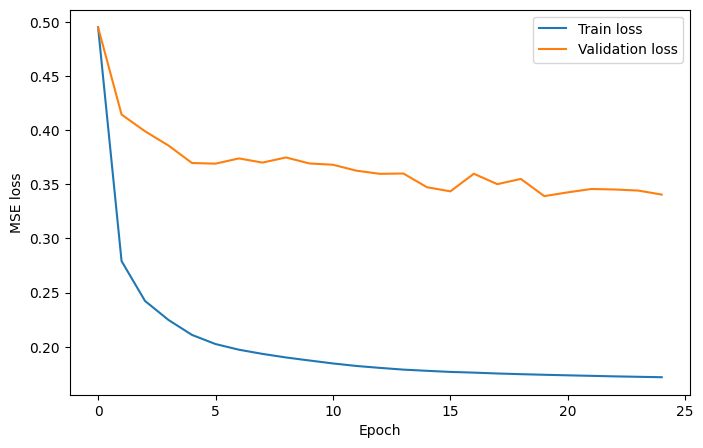

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.show()

In [96]:
X_val_pred = autoencoder.predict(X_val)

val_mse = np.mean(np.square(X_val - X_val_pred), axis=1)

print(val_mse[:10])
print("Mean validation MSE:", val_mse.mean())
print("Max validation MSE:", val_mse.max())

1287/1287 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
[0.09700869 0.09383687 0.10390567 0.10464163 0.09464565 0.10323234
 0.08753217 0.07707112 0.0710108  0.0710108 ]
Mean validation MSE: 0.3390862679229846
Max validation MSE: 134.5679910404931


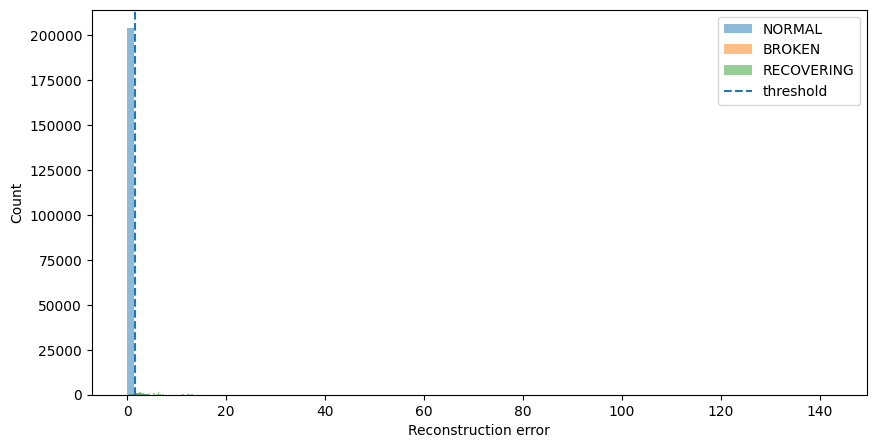

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for status in df["machine_status"].unique():
    subset = df[df["machine_status"] == status]
    plt.hist(
        subset["reconstruction_error"],
        bins=100,
        alpha=0.5,
        label=status
    )

plt.axvline(threshold, linestyle="--", label="threshold")
plt.xlabel("Reconstruction error")
plt.ylabel("Count")
plt.legend()
plt.show()